In [25]:
import pandas as pd

data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

hypothesis = ['0'] * 6

for _, row in df.iterrows():
    if row['EnjoySport'] == 'Yes':
        if hypothesis == ['0'] * 6:
            hypothesis = row.iloc[:6].tolist()
        else:
            for i in range(6):
                if hypothesis[i] != row.iloc[i]:
                    hypothesis[i] = '?'

print("Final Hypothesis:")
print(hypothesis)

Final Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


In [26]:
# EXPERIMENT 2: CANDIDATE ELIMINATION

import pandas as pd

df = pd.read_csv("EnjoySport.csv")

print("Dataset:")
display(df)

attributes = list(df.columns[:-1])
n = len(attributes)

# Specific boundary
S = ['0'] * n

# General boundary
G = [['?'] * n]

for _, row in df.iterrows():

    example = row.iloc[:-1].tolist()
    label = row.iloc[-1]

    # Positive example
    if label == "Yes":

        for i in range(n):

            if S[i] == '0':
                S[i] = example[i]

            elif S[i] != example[i]:
                S[i] = '?'

        G = [
            g for g in G
            if all(g[i] == '?' or g[i] == example[i]
                   for i in range(n))
        ]

    # Negative example
    else:

        new_G = []

        for g in G:

            for i in range(n):

                if g[i] == '?' and S[i] != '?':

                    if S[i] != example[i]:

                        new_g = g.copy()
                        new_g[i] = S[i]
                        new_G.append(new_g)

        G = new_G

print("\nSpecific Boundary:")
print(S)

print("\nGeneral Boundary:")
for g in G:
    print(g)

Dataset:


,Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
0,Sunny,Warm,Normal,Strong,Warm,Same,Yes
1,Sunny,Warm,High,Strong,Warm,Same,Yes
2,Rainy,Cold,High,Strong,Warm,Change,No
3,Sunny,Warm,High,Strong,Cool,Change,Yes



Specific Boundary:
['Sunny', 'Warm', '?', 'Strong', '?', '?']

General Boundary:
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']


Dataset:


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


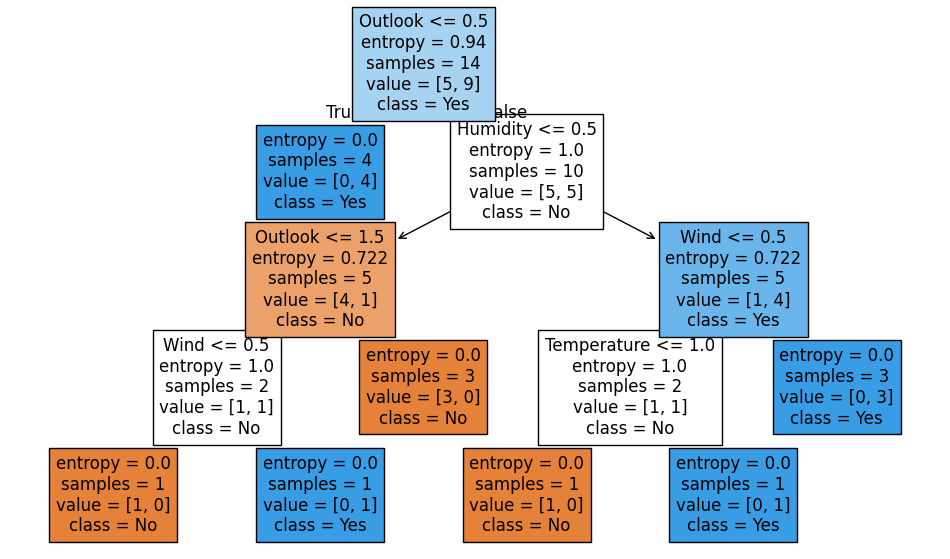

Predicted class: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [27]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

df = pd.read_csv("PlayTennis.csv")

print("Dataset:")
display(df)

# Encode categorical data
encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

X = df.drop("Play", axis=1)
y = df["Play"]

# ID3 uses entropy
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)

# Display tree
plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)

plt.show()

# New sample
new_sample = [[2, 0, 0, 0]]

prediction = model.predict(new_sample)

print("Predicted class:", prediction[0])

Dataset:


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


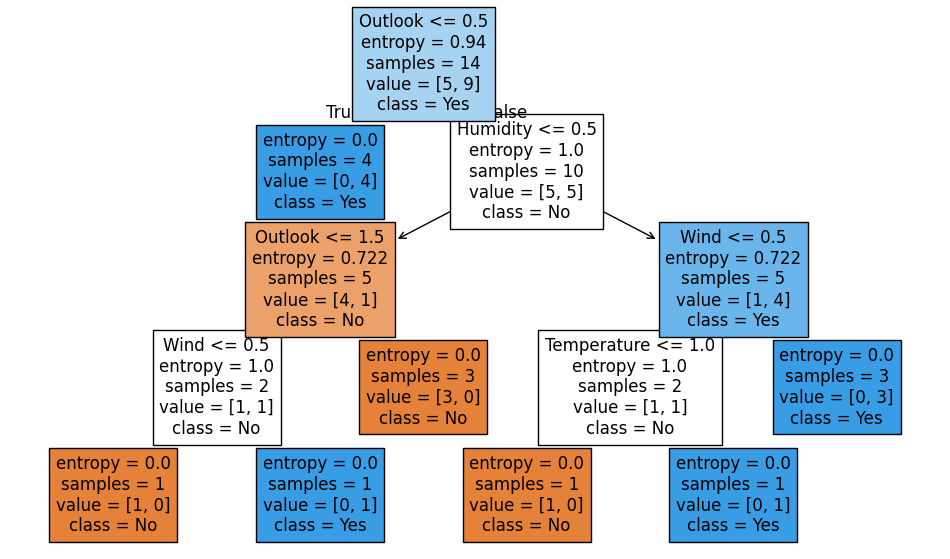

Predicted class: 0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [28]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

df = pd.read_csv("PlayTennis.csv")

print("Dataset:")
display(df)

# Encode categorical data
encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

X = df.drop("Play", axis=1)
y = df["Play"]

# ID3 uses entropy
model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)

# Display tree
plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True
)

plt.show()

# New sample
new_sample = [[2, 0, 0, 0]]

prediction = model.predict(new_sample)

print("Predicted class:", prediction[0])

In [29]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, prediction))

KNN Accuracy: 1.0


In [30]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [31]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("BreastCancer.csv")

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, prediction))

Logistic Regression Accuracy: 0.9736842105263158


In [32]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv("Diabetes.csv")

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Mean Squared Error:",
      mean_squared_error(y_test, prediction))

print("R2 Score:",
      r2_score(y_test, prediction))

Mean Squared Error: 2900.1936284934827
R2 Score: 0.45260276297191926


In [33]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv("PolynomialData.csv")

X = df[["X"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Linear Regression
# -----------------------------

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_prediction = linear_model.predict(X_test)

# -----------------------------
# Polynomial Regression
# -----------------------------

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

poly_prediction = poly_model.predict(X_test_poly)

# Results
print("LINEAR REGRESSION")
print("MSE:",
      mean_squared_error(y_test, linear_prediction))
print("R2:",
      r2_score(y_test, linear_prediction))

print("\nPOLYNOMIAL REGRESSION")
print("MSE:",
      mean_squared_error(y_test, poly_prediction))
print("R2:",
      r2_score(y_test, poly_prediction))

LINEAR REGRESSION
MSE: 182.40100866057628
R2: 0.9510199428986829

POLYNOMIAL REGRESSION
MSE: 2.9306839990525755
R2: 0.999213024803571


Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Cluster Means:
[[1.52059195 1.49346238]
 [8.45001795 8.48867134]]


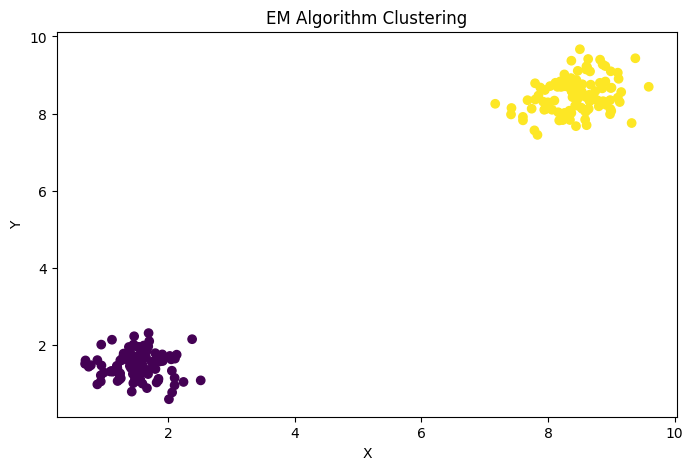

In [34]:

import pandas as pd

from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

df = pd.read_csv("EM_Clusters.csv")

X = df[["X", "Y"]]

# EM using Gaussian Mixture Model
model = GaussianMixture(
    n_components=2,
    random_state=42
)

model.fit(X)

labels = model.predict(X)

print("Cluster Labels:")
print(labels)

print("\nCluster Means:")
print(model.means_)

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    X["X"],
    X["Y"],
    c=labels
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("EM Algorithm Clustering")

plt.show()

In [35]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("Credit_Score.csv")

print("Dataset:")
display(df.head())

# Encode target
encoder = LabelEncoder()

df["Credit_Score"] = encoder.fit_transform(
    df["Credit_Score"]
)

X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Dataset:


,Age,Annual_Income,Num_Loans,Outstanding_Debt,Credit_History_Years,Payment_Score,Credit_Score
0,30,141064,5,19613,8,6,Good
1,39,135384,5,6458,18,8,Good
2,21,101736,2,46601,3,10,Good
3,59,71301,5,52133,9,3,Standard
4,51,101465,2,79259,5,1,Poor


Accuracy: 0.85

Confusion Matrix:
[[64  0  2]
 [ 0  7  3]
 [ 7  3 14]]


In [36]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("Credit_Score.csv")

print("Dataset:")
display(df.head())

# Encode target
encoder = LabelEncoder()

df["Credit_Score"] = encoder.fit_transform(
    df["Credit_Score"]
)

X = df.drop("Credit_Score", axis=1)
y = df["Credit_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Dataset:


,Age,Annual_Income,Num_Loans,Outstanding_Debt,Credit_History_Years,Payment_Score,Credit_Score
0,30,141064,5,19613,8,6,Good
1,39,135384,5,6458,18,8,Good
2,21,101736,2,46601,3,10,Good
3,59,71301,5,52133,9,3,Standard
4,51,101465,2,79259,5,1,Poor


Accuracy: 0.85

Confusion Matrix:
[[64  0  2]
 [ 0  7  3]
 [ 7  3 14]]


In [37]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()
df["Species"] = encoder.fit_transform(df["Species"])

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

# New flower
sample = [[5.1, 3.5, 1.4, 0.2]]

result = model.predict(sample)

print("Predicted Flower:",
      encoder.inverse_transform(result)[0])

Accuracy: 1.0
Predicted Flower: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [38]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv("HousePrice.csv")

print("Dataset:")
display(df.head())

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Mean Squared Error:",
      mean_squared_error(y_test, prediction))

print("R2 Score:",
      r2_score(y_test, prediction))

Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,6.984009,12.194712,7.800926,0.826169,181,1.026082,34.314369,-114.100665,3.013467
1,8.144563,25.365365,4.107645,1.555876,4021,4.185520,35.216867,-117.655764,3.739466
2,8.130204,45.599786,4.633549,1.273525,1026,1.539069,38.448017,-117.638879,3.689134
3,1.285159,26.501847,3.975274,2.191936,4138,3.393742,32.243575,-123.278363,1.390194
4,8.042641,3.824995,9.655109,0.839923,4059,2.301584,37.712191,-114.310083,3.685606


Mean Squared Error: 0.09971926246503475
R2 Score: 0.9490593862862489


In [39]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv("HousePrice.csv")

print("Dataset:")
display(df.head())

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Mean Squared Error:",
      mean_squared_error(y_test, prediction))

print("R2 Score:",
      r2_score(y_test, prediction))

Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,6.984009,12.194712,7.800926,0.826169,181,1.026082,34.314369,-114.100665,3.013467
1,8.144563,25.365365,4.107645,1.555876,4021,4.185520,35.216867,-117.655764,3.739466
2,8.130204,45.599786,4.633549,1.273525,1026,1.539069,38.448017,-117.638879,3.689134
3,1.285159,26.501847,3.975274,2.191936,4138,3.393742,32.243575,-123.278363,1.390194
4,8.042641,3.824995,9.655109,0.839923,4059,2.301584,37.712191,-114.310083,3.685606


Mean Squared Error: 0.09971926246503475
R2 Score: 0.9490593862862489


In [40]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv("HousePrice.csv")

print("Dataset:")
display(df.head())

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Mean Squared Error:",
      mean_squared_error(y_test, prediction))

print("R2 Score:",
      r2_score(y_test, prediction))

Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,6.984009,12.194712,7.800926,0.826169,181,1.026082,34.314369,-114.100665,3.013467
1,8.144563,25.365365,4.107645,1.555876,4021,4.185520,35.216867,-117.655764,3.739466
2,8.130204,45.599786,4.633549,1.273525,1026,1.539069,38.448017,-117.638879,3.689134
3,1.285159,26.501847,3.975274,2.191936,4138,3.393742,32.243575,-123.278363,1.390194
4,8.042641,3.824995,9.655109,0.839923,4059,2.301584,37.712191,-114.310083,3.685606


Mean Squared Error: 0.09971926246503475
R2 Score: 0.9490593862862489


In [41]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(
    df["Species"]
)

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

sample = [[5.1, 3.5, 1.4, 0.2]]

result = model.predict(sample)

print("Predicted Flower:",
      encoder.inverse_transform(result)[0])

Accuracy: 1.0
Predicted Flower: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [42]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(
    df["Species"]
)

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(n_neighbors=5),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
}

print("Algorithm Performance\n")

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    print(name, ":", accuracy)

Algorithm Performance

Logistic Regression : 1.0
KNN : 1.0
Naive Bayes : 1.0
Decision Tree : 1.0
Random Forest : 1.0


In [43]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("MobilePrice.csv")

print("Dataset:")
display(df.head())

X = df.drop("price_range", axis=1)
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Dataset:


,battery_power,ram,int_memory,pc,fc,screen_size,px_height,px_width,four_g,three_g,wifi,bluetooth,price_range
0,670,6287,220,19,18,4.6,577,2169,0,1,0,1,3
1,901,2837,22,2,1,6.2,1160,1520,0,1,1,1,0
2,503,4881,12,8,14,5.8,1426,790,0,1,0,0,0
3,1208,1692,30,13,16,5.2,1448,1476,0,1,0,1,0
4,755,4827,224,12,0,4.8,1752,2455,1,0,0,0,3


Accuracy: 0.8775

Confusion Matrix:
[[103  10   0   0]
 [  6  83   6   0]
 [  0   6  84   6]
 [  0   0  15  81]]


In [44]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("MobilePrice.csv")

print("Dataset:")
display(df.head())

X = df.drop("price_range", axis=1)
y = df["price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, prediction))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

Dataset:


,battery_power,ram,int_memory,pc,fc,screen_size,px_height,px_width,four_g,three_g,wifi,bluetooth,price_range
0,670,6287,220,19,18,4.6,577,2169,0,1,0,1,3
1,901,2837,22,2,1,6.2,1160,1520,0,1,1,1,0
2,503,4881,12,8,14,5.8,1426,790,0,1,0,0,0
3,1208,1692,30,13,16,5.2,1448,1476,0,1,0,1,0
4,755,4827,224,12,0,4.8,1752,2455,1,0,0,0,3


Accuracy: 0.8775

Confusion Matrix:
[[103  10   0   0]
 [  6  83   6   0]
 [  0   6  84   6]
 [  0   0  15  81]]


In [45]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(
    df["Species"]
)

# Use two classes for binary Perceptron classification
df = df[df["Species"] < 2]

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Perceptron(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Perceptron Accuracy:",
      accuracy_score(y_test, prediction))

Perceptron Accuracy: 1.0


In [46]:

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

df = pd.read_csv("Iris.csv")

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(
    df["Species"]
)

# Use two classes for binary Perceptron classification
df = df[df["Species"] < 2]

X = df[[
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth"
]]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Perceptron(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Perceptron Accuracy:",
      accuracy_score(y_test, prediction))

Perceptron Accuracy: 1.0


In [47]:


import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

df = pd.read_csv("Sales.csv")

print("Dataset:")
display(df.head())

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

# Extract date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

X = df[
    ["Year", "Month", "Day", "DayOfWeek"]
]

y = df["Sales"]

# Chronological split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Mean Squared Error:",
      mean_squared_error(y_test, prediction))

print("R2 Score:",
      r2_score(y_test, prediction))

print("\nFirst 10 Future Sales Predictions:")

for i in range(10):
    print(
        "Actual:",
        round(y_test.iloc[i], 2),
        "Predicted:",
        round(prediction[i], 2)
    )

Dataset:


,Date,Sales
0,2023-01-01,202.54
1,2023-01-02,200.36
2,2023-01-03,209.77
3,2023-01-04,208.95
4,2023-01-05,227.76


Mean Squared Error: 819.2424432457542
R2 Score: -0.29832567612450034

First 10 Future Sales Predictions:
Actual: 388.71 Predicted: 384.28
Actual: 348.18 Predicted: 374.73
Actual: 364.19 Predicted: 378.4
Actual: 394.71 Predicted: 376.21
Actual: 359.84 Predicted: 373.17
Actual: 360.89 Predicted: 370.71
Actual: 352.68 Predicted: 366.46
Actual: 380.25 Predicted: 368.73
Actual: 354.04 Predicted: 361.24
Actual: 339.23 Predicted: 365.11
